TASK 2: Data Preprocessing



[*********************100%***********************]  5 of 5 completed


✓ Downloaded: 1235 rows × 5 stocks

── Step 4: Handling Missing Values ──
Missing values BEFORE filling:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
M&M.NS           0
SUNPHARMA.NS     0
dtype: int64

Missing values AFTER filling:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
M&M.NS           0
SUNPHARMA.NS     0
dtype: int64
✓ All missing values handled


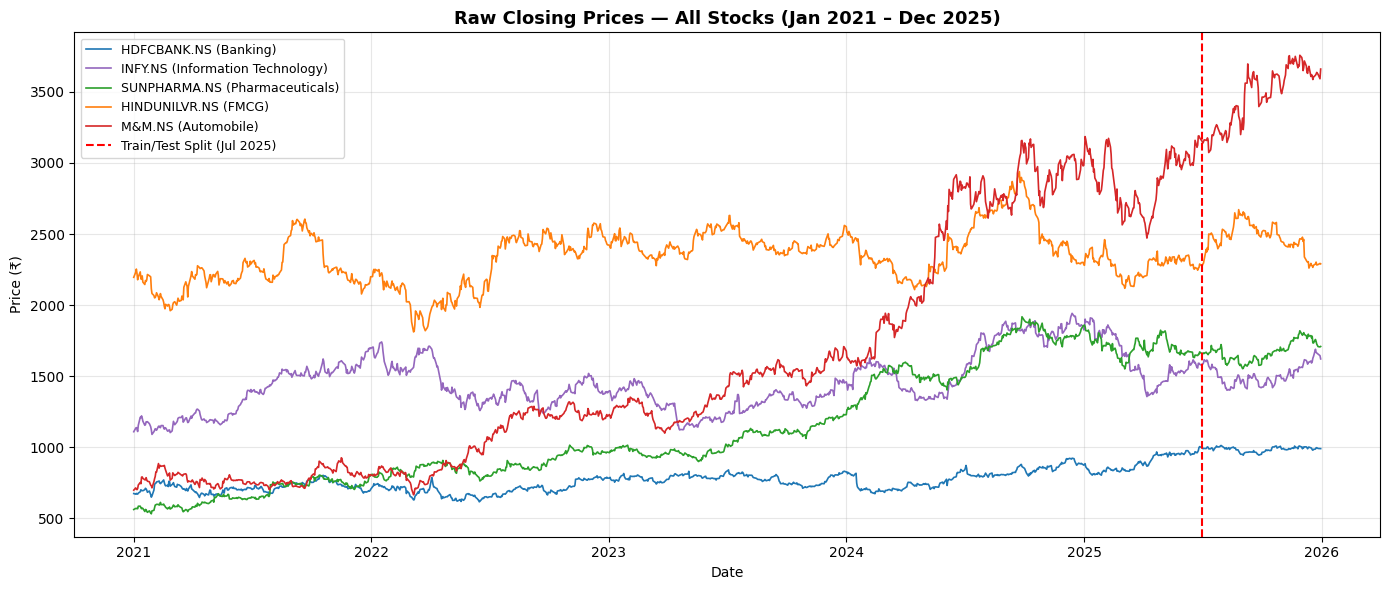

✓ Saved: task2_raw_prices.png

── Step 5: Train / Test Split ──
Training set : 2021-01-01 → 2025-06-30 (1110 days)
Test set     : 2025-07-01  → 2025-12-30  (125 days)
✓ Saved: train_data.csv and test_data.csv


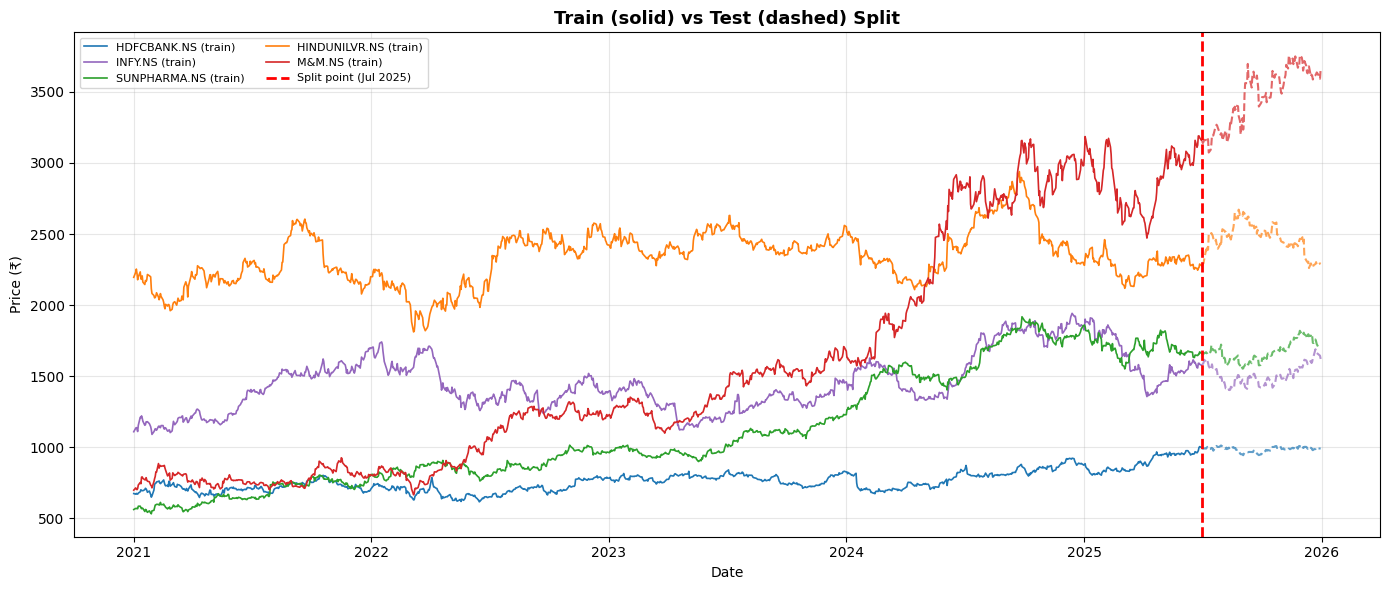

✓ Saved: task2_train_test_split.png

── Step 6: ADF Test on Raw Prices ──

Stock              Series            ADF Stat   p-value  Result
----------------------------------------------------------------------
  HDFCBANK.NS        Raw price       ADF= -1.4167  p=0.5742  → Non-stationary ✗
  INFY.NS            Raw price       ADF= -2.2509  p=0.1883  → Non-stationary ✗
  SUNPHARMA.NS       Raw price       ADF= -0.6606  p=0.8567  → Non-stationary ✗
  HINDUNILVR.NS      Raw price       ADF= -2.6978  p=0.0744  → Non-stationary ✗
  M&M.NS             Raw price       ADF=  0.3997  p=0.9815  → Non-stationary ✗

── ADF Test After 1st-Order Differencing ──

Stock              Series            ADF Stat   p-value  Result
----------------------------------------------------------------------
  HDFCBANK.NS        1st diff        ADF=-14.0353  p=0.0000  → Stationary ✓
  INFY.NS            1st diff        ADF=-34.0327  p=0.0000  → Stationary ✓
  SUNPHARMA.NS       1st diff        ADF=-10.1058  p=0.00

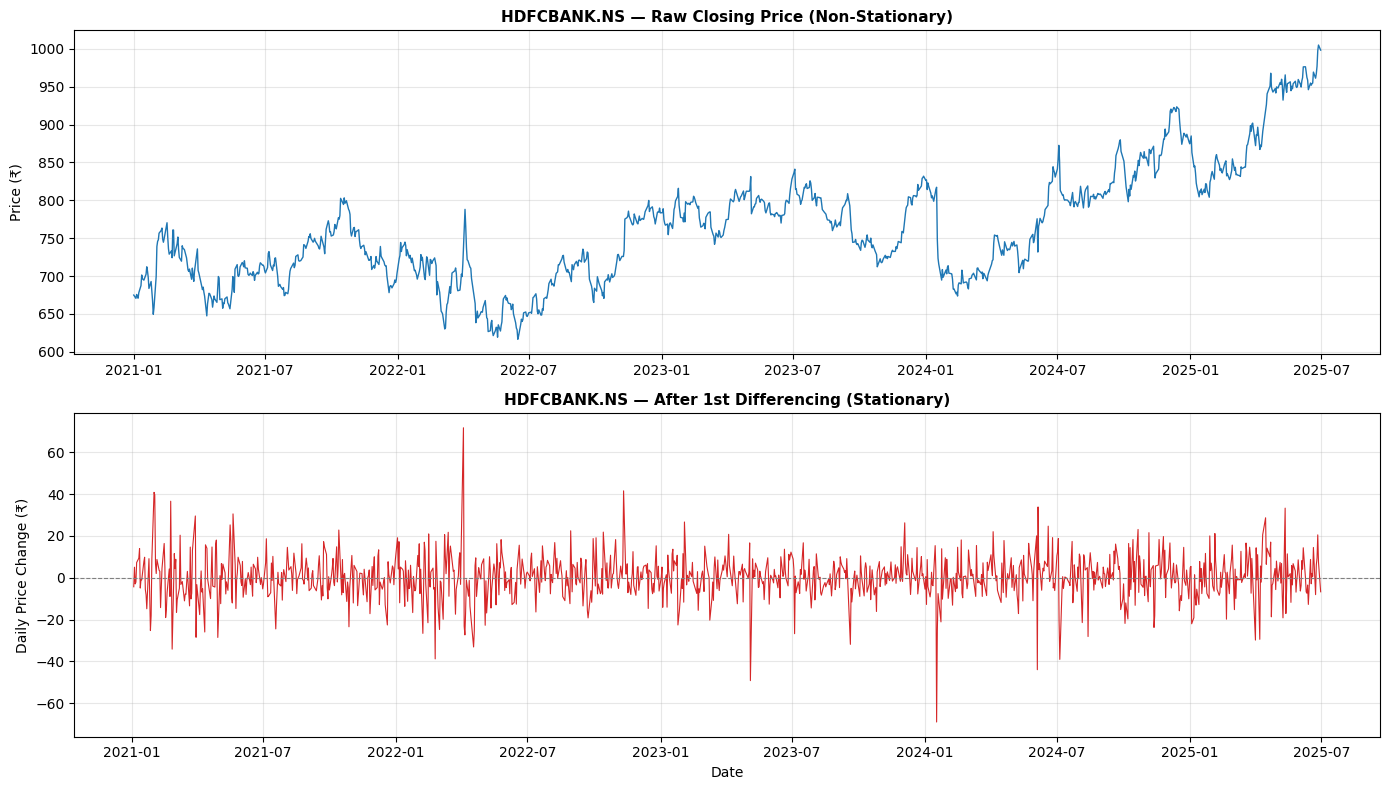

✓ Saved: task2_differencing.png

── Step 7: MinMax Normalization (for LSTM) ──
✓ MinMax scaling applied (range: 0 to 1)

Sample scaled training values (HDFCBANK):
Date
2021-01-01    0.1503
2021-01-04    0.1392
2021-01-05    0.1523
2021-01-06    0.1448
2021-01-07    0.1395
Name: HDFCBANK.NS, dtype: float64

Sample scaled test values (HDFCBANK):
Date
2025-07-01    0.9964
2025-07-02    0.9629
2025-07-03    0.9643
2025-07-04    0.9671
2025-07-07    0.9647
Name: HDFCBANK.NS, dtype: float64

✓ Saved: scalers.pkl (needed for Task 3 LSTM inverse transform)
✓ Saved: train_scaled.csv and test_scaled.csv


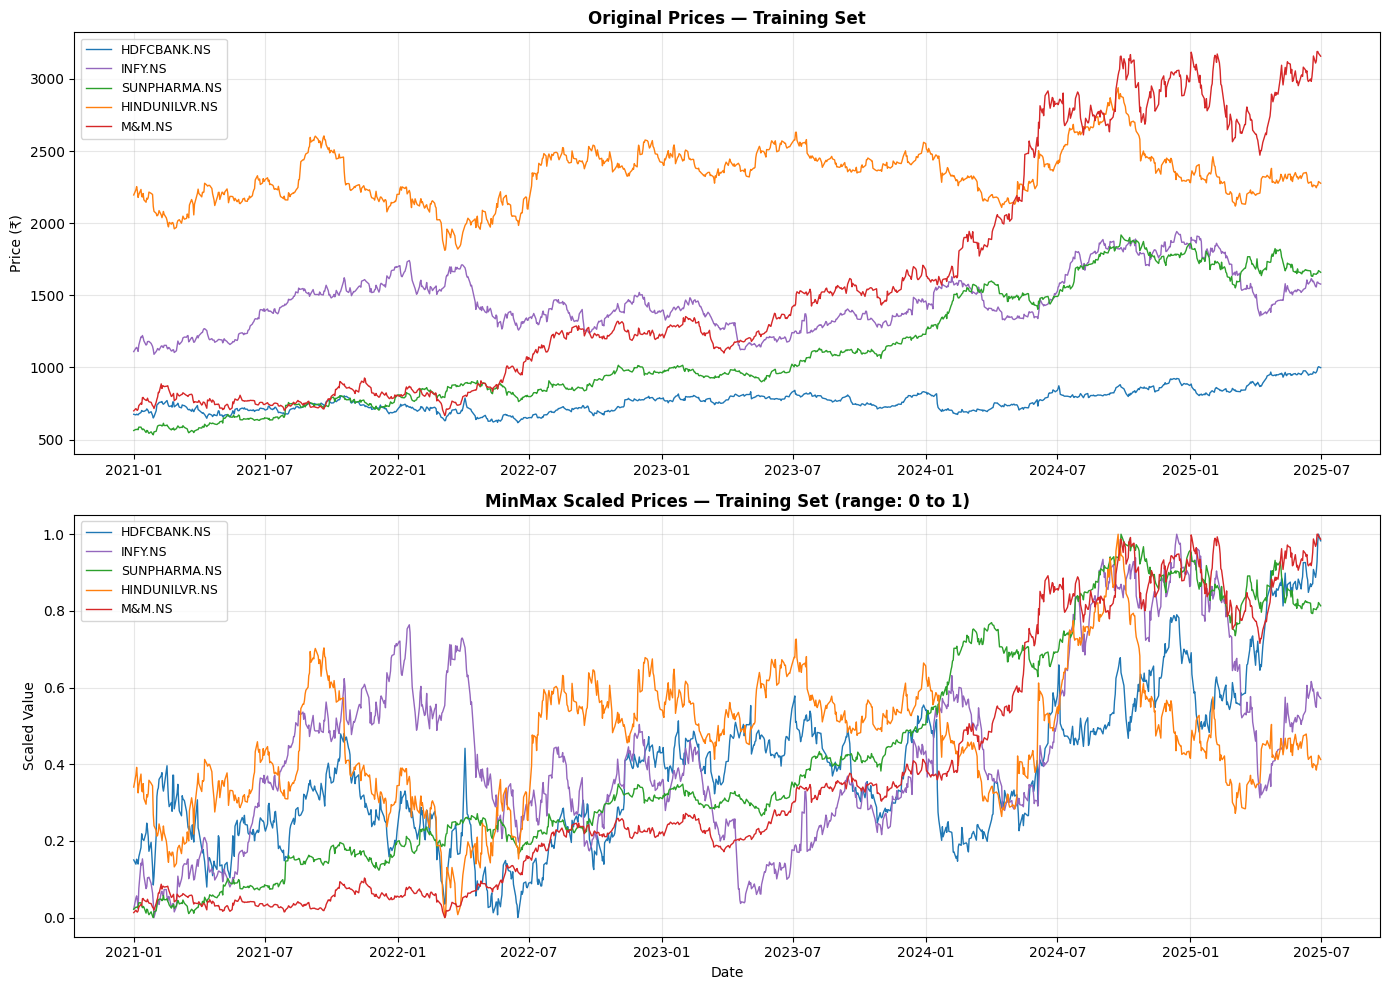

✓ Saved: task2_normalization.png

── Step 8: Computing Log Returns ──
Log Returns — Summary Statistics:
Ticker  HDFCBANK.NS  HINDUNILVR.NS    INFY.NS     M&M.NS  SUNPHARMA.NS
count     1234.0000      1234.0000  1234.0000  1234.0000     1234.0000
mean         0.0003         0.0000     0.0003     0.0013        0.0009
std          0.0134         0.0127     0.0152     0.0179        0.0131
min         -0.0881        -0.0769    -0.0990    -0.0684       -0.0466
25%         -0.0065        -0.0068    -0.0083    -0.0092       -0.0066
50%          0.0005        -0.0003     0.0004     0.0010        0.0006
75%          0.0070         0.0066     0.0091     0.0109        0.0079
max          0.0954         0.0579     0.0763     0.0765        0.0962

✓ Saved: log_returns.csv (needed for Task 4 volatility analysis)


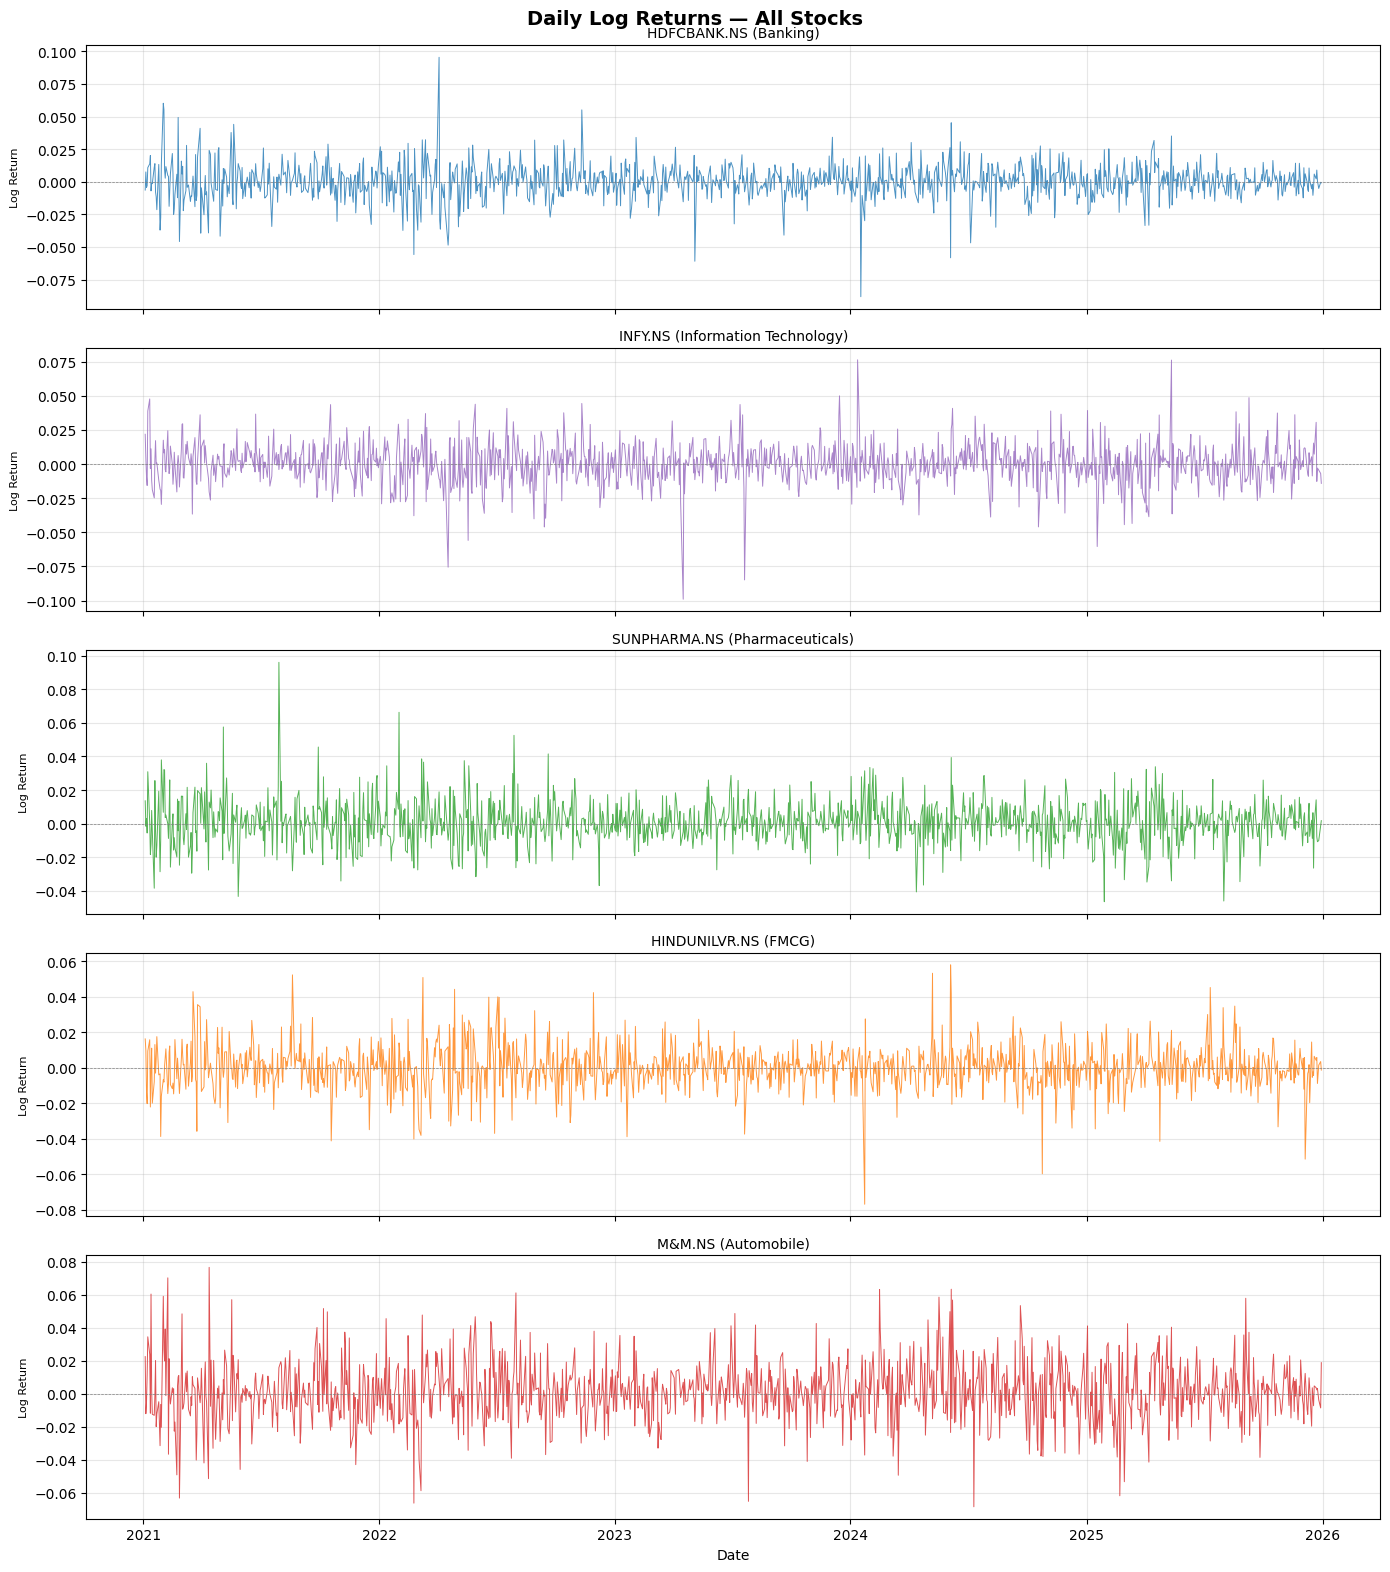

✓ Saved: task2_log_returns.png

TASK 2 COMPLETE ✓

Files saved for use in later tasks:
  train_data.csv      → Raw training prices (Task 3, 4, 5)
  test_data.csv       → Raw test prices     (Task 3, 8)
  train_scaled.csv    → Scaled train data   (Task 3 LSTM)
  test_scaled.csv     → Scaled test data    (Task 3 LSTM)
  log_returns.csv     → Log returns         (Task 4)
  scalers.pkl         → MinMax scalers      (Task 3 LSTM)

Plots saved:
  task2_raw_prices.png
  task2_train_test_split.png
  task2_differencing.png
  task2_normalization.png
  task2_log_returns.png

Key findings:
  HDFCBANK.NS        Raw: Non-stationary   → After diff: Stationary ✓
  INFY.NS            Raw: Non-stationary   → After diff: Stationary ✓
  SUNPHARMA.NS       Raw: Non-stationary   → After diff: Stationary ✓
  HINDUNILVR.NS      Raw: Non-stationary   → After diff: Stationary ✓
  M&M.NS             Raw: Non-stationary   → After diff: Stationary ✓

Next → Task 3: Time Series Forecasting (ARIMA + Prophet + LSTM)


In [ ]:
# ============================================================
# CAPSTONE PROJECT — Time Series Analysis 2026
# TASK 2: Data Preprocessing
# Consulting & Analytics Club, IIT Guwahati
# ============================================================
#
# What we do in this task:
#   1. Re-download and clean the data (handle missing values)
#   2. ADF test → apply differencing to non-stationary series
#   3. Normalize data using MinMax scaling (for LSTM in Task 3)
#   4. Split into Train (Jan 2021 – Jun 2025) and Test (Jul 2025 – Dec 2025)
#   5. Save everything for use in Task 3
# ============================================================


# ── STEP 1: Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import pickle   # To save the scaler object for use in Task 3
import warnings
warnings.filterwarnings('ignore')


# ── STEP 2: Define stocks (same as Task 1)
STOCKS = {
    "HDFCBANK.NS":   "Banking",
    "INFY.NS":       "Information Technology",
    "SUNPHARMA.NS":  "Pharmaceuticals",
    "HINDUNILVR.NS": "FMCG",
    "M&M.NS":        "Automobile"
}

START_DATE  = "2021-01-01"
END_DATE    = "2025-12-31"
TRAIN_END   = "2025-06-30"   # Everything up to this date = training data
TEST_START  = "2025-07-01"   # Last 6 months = test/validation data

print("=" * 60)
print("TASK 2: Data Preprocessing")
print("=" * 60)


# ── STEP 3: Download data
print("\nDownloading data...")
raw_data = yf.download(
    tickers=list(STOCKS.keys()),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True
)

# Handle MultiIndex columns (yfinance sometimes returns nested columns)
if isinstance(raw_data.columns, pd.MultiIndex):
    close_prices = raw_data["Close"]
else:
    close_prices = raw_data[["Close"]]

print(f"✓ Downloaded: {close_prices.shape[0]} rows × {close_prices.shape[1]} stocks")


# ============================================================
# STEP 4: Handle Missing Values
# Stock markets are closed on weekends and public holidays.
# Those days have NaN (missing) values in the data.
# We use forward-fill: fill the gap with the last known price.
# ============================================================

print("\n── Step 4: Handling Missing Values ──")
print("Missing values BEFORE filling:")
print(close_prices.isnull().sum())

# Forward fill first (use last known price)
close_prices = close_prices.ffill()

# Backward fill for any remaining NaNs at the very start
close_prices = close_prices.bfill()

print("\nMissing values AFTER filling:")
print(close_prices.isnull().sum())
print("✓ All missing values handled")


# ── Plot raw closing prices
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1f77b4', '#9467bd', '#2ca02c', '#ff7f0e', '#d62728']
for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ax.plot(close_prices.index, close_prices[ticker],
            label=f"{ticker} ({sector})", color=colors[idx], linewidth=1.2)
ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--',
           linewidth=1.5, label='Train/Test Split (Jul 2025)')
ax.set_title("Raw Closing Prices — All Stocks (Jan 2021 – Dec 2025)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task2_raw_prices.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task2_raw_prices.png")


# ============================================================
# STEP 5: Train / Test Split
# Train : Jan 2021 – Jun 2025 (everything before Jul 2025)
# Test  : Jul 2025 – Dec 2025 (last 6 months — held out)
# We NEVER touch the test set during model training.
# ============================================================

print("\n── Step 5: Train / Test Split ──")

train_data = close_prices.loc[:TRAIN_END]
test_data  = close_prices.loc[TEST_START:]

print(f"Training set : {train_data.index[0].date()} → {train_data.index[-1].date()} ({len(train_data)} days)")
print(f"Test set     : {test_data.index[0].date()}  → {test_data.index[-1].date()}  ({len(test_data)} days)")

# Save train/test splits as CSV for use in later tasks
train_data.to_csv("train_data.csv")
test_data.to_csv("test_data.csv")
print("✓ Saved: train_data.csv and test_data.csv")


# ── Visualize the split
fig, ax = plt.subplots(figsize=(14, 6))
for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ax.plot(train_data.index, train_data[ticker],
            color=colors[idx], linewidth=1.2, label=f"{ticker} (train)")
    ax.plot(test_data.index, test_data[ticker],
            color=colors[idx], linewidth=1.5, linestyle='--', alpha=0.7)

ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--',
           linewidth=2, label='Split point (Jul 2025)')
ax.set_title("Train (solid) vs Test (dashed) Split", fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("task2_train_test_split.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task2_train_test_split.png")


# ============================================================
# STEP 6: ADF Stationarity Test + Differencing
#
# Most stock price series are NON-STATIONARY:
#   → They have a trend (prices generally go up over time)
#   → Their mean and variance change over time
#
# ARIMA models need STATIONARY data.
# Solution: Apply 1st-order differencing:
#   differenced[t] = price[t] - price[t-1]
# This converts "price levels" into "daily changes"
# ============================================================

print("\n── Step 6: ADF Test on Raw Prices ──")

def run_adf_test(series, ticker, label=""):
    """Run ADF test and return results as a dict."""
    series = series.dropna()
    if len(series) < 20:
        return None
    result        = adfuller(series, autolag='AIC')
    adf_stat      = result[0]
    p_value       = result[1]
    is_stationary = p_value < 0.05
    status        = "Stationary ✓" if is_stationary else "Non-stationary ✗"
    print(f"  {ticker:<18} {label:<15} ADF={adf_stat:>8.4f}  p={p_value:.4f}  → {status}")
    return {"ticker": ticker, "adf": adf_stat, "pvalue": p_value, "stationary": is_stationary}

print(f"\n{'Stock':<18} {'Series':<15} {'ADF Stat':>10}  {'p-value':>8}  {'Result'}")
print("-" * 70)

# Test raw (level) prices
adf_raw = {}
for ticker in STOCKS.keys():
    res = run_adf_test(train_data[ticker], ticker, label="Raw price")
    if res:
        adf_raw[ticker] = res

# Apply 1st-order differencing and re-test
print("\n── ADF Test After 1st-Order Differencing ──")
print(f"\n{'Stock':<18} {'Series':<15} {'ADF Stat':>10}  {'p-value':>8}  {'Result'}")
print("-" * 70)

differenced_data = close_prices.diff().dropna()  # diff() = price[t] - price[t-1]

adf_diff = {}
for ticker in STOCKS.keys():
    res = run_adf_test(differenced_data[ticker], ticker, label="1st diff")
    if res:
        adf_diff[ticker] = res

print("\nNote: After 1st differencing, all series should be stationary.")
print("This confirms d=1 parameter for ARIMA models in Task 3.")


# ── Plot: Raw vs Differenced for one stock (HDFCBANK as example)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_data.index, train_data["HDFCBANK.NS"],
             color='#1f77b4', linewidth=1)
axes[0].set_title("HDFCBANK.NS — Raw Closing Price (Non-Stationary)",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel("Price (₹)")
axes[0].grid(True, alpha=0.3)

diff_train = train_data["HDFCBANK.NS"].diff().dropna()
axes[1].plot(diff_train.index, diff_train,
             color='#d62728', linewidth=0.8)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title("HDFCBANK.NS — After 1st Differencing (Stationary)",
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel("Daily Price Change (₹)")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task2_differencing.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task2_differencing.png")


# ============================================================
# STEP 7: Normalization / Scaling (for LSTM in Task 3)
#
# LSTM neural networks are sensitive to the scale of input data.
# A price of ₹1500 (INFY) vs ₹500 (HINDUNILVR) would confuse
# the model if used as-is.
#
# MinMax Scaling transforms all values to the range [0, 1]:
#   scaled = (value - min) / (max - min)
#
# IMPORTANT: We fit the scaler ONLY on training data,
# then apply the same scaler to test data.
# (This prevents "data leakage" — the model shouldn't know
#  anything about the test period during training.)
# ============================================================

print("\n── Step 7: MinMax Normalization (for LSTM) ──")

scalers       = {}   # Store one scaler per stock
train_scaled  = pd.DataFrame(index=train_data.index)
test_scaled   = pd.DataFrame(index=test_data.index)

for ticker in STOCKS.keys():
    scaler = MinMaxScaler(feature_range=(0, 1))

    # Fit scaler on TRAINING data only
    train_values = train_data[ticker].values.reshape(-1, 1)
    scaler.fit(train_values)

    # Transform both train and test using the same scaler
    train_scaled[ticker] = scaler.transform(train_values).flatten()
    test_scaled[ticker]  = scaler.transform(
        test_data[ticker].values.reshape(-1, 1)
    ).flatten()

    scalers[ticker] = scaler  # Save scaler for inverse transform later

print("✓ MinMax scaling applied (range: 0 to 1)")
print("\nSample scaled training values (HDFCBANK):")
print(train_scaled["HDFCBANK.NS"].head(5).round(4))
print("\nSample scaled test values (HDFCBANK):")
print(test_scaled["HDFCBANK.NS"].head(5).round(4))

# Save scalers for use in Task 3 (LSTM)
with open("scalers.pkl", "wb") as f:
    pickle.dump(scalers, f)
print("\n✓ Saved: scalers.pkl (needed for Task 3 LSTM inverse transform)")

# Save scaled data
train_scaled.to_csv("train_scaled.csv")
test_scaled.to_csv("test_scaled.csv")
print("✓ Saved: train_scaled.csv and test_scaled.csv")


# ── Plot: Original vs Scaled for all stocks
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, (ticker, sector) in enumerate(STOCKS.items()):
    axes[0].plot(train_data.index, train_data[ticker],
                 color=colors[idx], linewidth=1, label=f"{ticker}")
    axes[1].plot(train_scaled.index, train_scaled[ticker],
                 color=colors[idx], linewidth=1, label=f"{ticker}")

axes[0].set_title("Original Prices — Training Set", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Price (₹)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("MinMax Scaled Prices — Training Set (range: 0 to 1)",
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel("Scaled Value")
axes[1].set_xlabel("Date")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("task2_normalization.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task2_normalization.png")


# ============================================================
# STEP 8: Log Returns (needed for Task 4 Volatility Analysis)
#
# Log return = ln(price[t] / price[t-1])
# Used instead of simple % returns because:
#   - They are additive over time
#   - More symmetric (handles gains and losses equally)
#   - Standard in financial time series analysis
# ============================================================

print("\n── Step 8: Computing Log Returns ──")

log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

print("Log Returns — Summary Statistics:")
print(log_returns.describe().round(4))

# Save log returns for Task 4
log_returns.to_csv("log_returns.csv")
print("\n✓ Saved: log_returns.csv (needed for Task 4 volatility analysis)")

# Plot log returns
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle("Daily Log Returns — All Stocks", fontsize=14, fontweight='bold')

for idx, (ticker, sector) in enumerate(STOCKS.items()):
    ax = axes[idx]
    ax.plot(log_returns.index, log_returns[ticker],
            color=colors[idx], linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel("Log Return", fontsize=8)
    ax.set_title(f"{ticker} ({sector})", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig("task2_log_returns.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: task2_log_returns.png")


# ── FINAL SUMMARY
print("\n" + "=" * 60)
print("TASK 2 COMPLETE ✓")
print("=" * 60)
print("\nFiles saved for use in later tasks:")
print("  train_data.csv      → Raw training prices (Task 3, 4, 5)")
print("  test_data.csv       → Raw test prices     (Task 3, 8)")
print("  train_scaled.csv    → Scaled train data   (Task 3 LSTM)")
print("  test_scaled.csv     → Scaled test data    (Task 3 LSTM)")
print("  log_returns.csv     → Log returns         (Task 4)")
print("  scalers.pkl         → MinMax scalers      (Task 3 LSTM)")
print("\nPlots saved:")
print("  task2_raw_prices.png")
print("  task2_train_test_split.png")
print("  task2_differencing.png")
print("  task2_normalization.png")
print("  task2_log_returns.png")
print("\nKey findings:")

for ticker in STOCKS.keys():
    if ticker in adf_raw and ticker in adf_diff:
        raw_stat = "Non-stationary" if not adf_raw[ticker]["stationary"] else "Stationary"
        diff_stat = "Stationary ✓" if adf_diff[ticker]["stationary"] else "Still non-stationary"
        print(f"  {ticker:<18} Raw: {raw_stat:<16} → After diff: {diff_stat}")

print("\nNext → Task 3: Time Series Forecasting (ARIMA + Prophet + LSTM)")
print("=" * 60)

In [1]:
import yfinance as yf
import pandas as pd

STOCKS = {
    "HDFCBANK.NS":   "Banking",
    "INFY.NS":       "IT",
    "SUNPHARMA.NS":  "Pharma",
    "HINDUNILVR.NS": "FMCG",
    "M&M.NS":        "Auto"
}

# Total virtual capital
TOTAL_CAPITAL = 1000000  # ₹10,00,000

# Allocation weights (we'll refine in Task 5, but this is a good start)
WEIGHTS = {
    "HDFCBANK.NS":   0.25,
    "INFY.NS":       0.20,
    "SUNPHARMA.NS":  0.20,
    "HINDUNILVR.NS": 0.20,
    "M&M.NS":        0.15
}

print(f"{'Stock':<18} {'Sector':<8} {'Price (₹)':>10} {'Allocation (₹)':>16} {'No. of Shares':>14}")
print("-" * 72)

for ticker, sector in STOCKS.items():
    data          = yf.download(ticker, period="1d", interval="1m", progress=False)
    current_price = round(float(data["Close"].iloc[-1]), 2)
    allocation    = TOTAL_CAPITAL * WEIGHTS[ticker]
    num_shares    = int(allocation // current_price)  # floor — don't overspend
    actual_spent  = round(num_shares * current_price, 2)

    print(f"{ticker:<18} {sector:<8} {current_price:>10.2f} {allocation:>16.0f} {num_shares:>14}")

print("-" * 72)
print(f"\nRun this in Colab to get today's exact share counts!")

Stock              Sector    Price (₹)   Allocation (₹)  No. of Shares
------------------------------------------------------------------------


/tmp/ipykernel_2949/2860126430.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data          = yf.download(ticker, period="1d", interval="1m", progress=False)
/tmp/ipykernel_2949/2860126430.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = round(float(data["Close"].iloc[-1]), 2)
/tmp/ipykernel_2949/2860126430.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data          = yf.download(ticker, period="1d", interval="1m", progress=False)


HDFCBANK.NS        Banking      766.00           250000            326


/tmp/ipykernel_2949/2860126430.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = round(float(data["Close"].iloc[-1]), 2)
/tmp/ipykernel_2949/2860126430.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data          = yf.download(ticker, period="1d", interval="1m", progress=False)


INFY.NS            IT          1176.00           200000            170


/tmp/ipykernel_2949/2860126430.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = round(float(data["Close"].iloc[-1]), 2)
/tmp/ipykernel_2949/2860126430.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data          = yf.download(ticker, period="1d", interval="1m", progress=False)


SUNPHARMA.NS       Pharma      1872.70           200000            106


/tmp/ipykernel_2949/2860126430.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = round(float(data["Close"].iloc[-1]), 2)
/tmp/ipykernel_2949/2860126430.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data          = yf.download(ticker, period="1d", interval="1m", progress=False)


HINDUNILVR.NS      FMCG        2305.60           200000             86
M&M.NS             Auto        3245.90           150000             46
------------------------------------------------------------------------

Run this in Colab to get today's exact share counts!


/tmp/ipykernel_2949/2860126430.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = round(float(data["Close"].iloc[-1]), 2)
